We check if the predictions from our theory match the simulations.

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import scipy
import scipy.linalg
import gaussian_crossings.utils as utils
import gaussian_crossings.formula as formula
import gaussian_crossings.process as process

### For the OU noise process

In [8]:
# Simulation parameters.
T = 10.0                 # Total simulation time.
tau_e = 0.06            # Correlation decay parameter for the process.
tau_f = 0.005           # Second correlation parameter.
dt = 0.1 * min(tau_e, tau_f)  # Time discretization step.
sigma = 1.0             # Standard deviation (amplitude) of the process.
u = 0.5                 # Threshold for upcrossings.
n_trials = 10000       # Number of simulation trials.

# Containers for simulation results.
upcrossings_counts = np.zeros(n_trials)

# Run the simulations.
for trial in range(n_trials):
    # Simulate one sample path of the process.
    t, x = utils.simulate_gaussian_process_fft(
        process.r_OU_noise, T, dt, sigma=sigma, tau=tau_e, kappa=tau_f/tau_e
    )
    # Count the number of upcrossings at threshold u.
    upcrossings_counts[trial] = utils.count_upcrossings(x, threshold=u)

Simulation results:
Mean upcrossings: 17.7735
Variance of upcrossings: 32.5986
Fano factor (variance/mean): 1.8341

Analytical results:
Expected number of upcrossings (mean): 18.0938
Variance of upcrossings: 30.7029
Fano factor (variance/mean): 1.6969


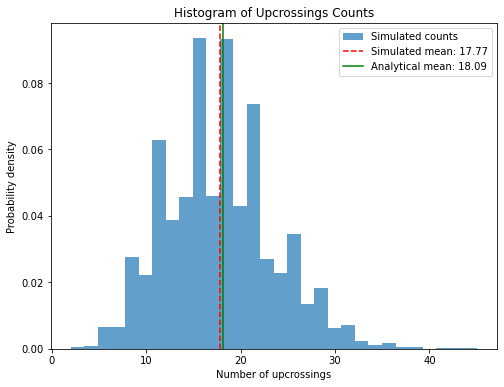

In [9]:
# Calculate empirical statistics.
sim_mean = np.mean(upcrossings_counts)
sim_var = np.var(upcrossings_counts)
sim_fano = sim_var / sim_mean if sim_mean != 0 else np.nan

print("Simulation results:")
print(f"Mean upcrossings: {sim_mean:.4f}")
print(f"Variance of upcrossings: {sim_var:.4f}")
print(f"Fano factor (variance/mean): {sim_fano:.4f}")

# Compute analytical results using your GaussianUpCrossingsDimless class.
# (Note: the analytical formulas assume a dimensionless time scale with tau set to 1 in r(t).
# Here we pass tau=tau_e to keep parameters consistent with the simulation.)
gaussian_up = formula.GaussianUpCrossingsDimless(r_func=process.r_OU_noise, u=u, tau=tau_e, kappa=tau_f/tau_e, sigma=sigma)

analytical_mean = gaussian_up.upcrossing_mean(T, u=u).item()
analytical_variance = gaussian_up.upcrossing_variance(T, u=u).item()
analytical_fano = gaussian_up.upcrossing_fano_factor(T, u=u).item()

print("\nAnalytical results:")
print(f"Expected number of upcrossings (mean): {analytical_mean:.4f}")
print(f"Variance of upcrossings: {analytical_variance:.4f}")
print(f"Fano factor (variance/mean): {analytical_fano:.4f}")

# Plot histogram of simulation upcrossings counts with the analytical mean indicated.
plt.figure(figsize=(8, 6))
plt.hist(upcrossings_counts, bins=30, density=True, alpha=0.7, label="Simulated counts")
plt.axvline(sim_mean, color='r', linestyle='--', 
            label=f"Simulated mean: {sim_mean:.2f}")
plt.axvline(analytical_mean, color='g', linestyle='-', 
            label=f"Analytical mean: {analytical_mean:.2f}")
plt.xlabel("Number of upcrossings")
plt.ylabel("Probability density")
plt.title("Histogram of Upcrossings Counts")
plt.legend()
plt.show()